In [ ]:
from google.colab import files

uploaded = files.upload()


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [ ]:
import pandas as pd

data = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

data.shape

(4000, 28)

In [ ]:
data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
data.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
data["Rainfall_mm"] = data["Rainfall_mm"].fillna(data["Rainfall_mm"].median())

data["Soil_Moisture_pct"] = data["Soil_Moisture_pct"].fillna(data["Soil_Moisture_pct"].median())

data["Yield_Tonnes_Ha"] = data["Yield_Tonnes_Ha"].fillna(data["Yield_Tonnes_Ha"].median())

In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data["Farm_ID"].nunique()

4000

In [ ]:
data["Crop"].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [ ]:
data["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [ ]:
data["State"].value_counts()

,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


Q1. Which season has the highest average crop yield?

In [ ]:
data.groupby("Season")["Yield_Tonnes_Ha"].mean()

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


Conclusion:
Kharif has the highest average crop yield at approximately 5.63 tonnes/ha.

Q2. Which season generates the highest average profit?

In [ ]:
data.groupby("Season")["Profit_INR"].mean()

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


Conclusion: Kharif has the highest average profit of approximately ₹1.79 lakh, while Zaid shows an average loss of approximately ₹24,805.

Q3. Which crop has the highest average yield?

In [ ]:
data.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


Conclusion: Sugarcane has the highest average crop yield at approximately 46.64 tonnes/ha, while Pulses has the lowest average yield at approximately 0.92 tonnes/ha.

Q4. Which crop generates the highest average profit?

In [ ]:
data.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


Conclusion: Sugarcane generates the highest average profit of approximately ₹8.17 lakh, while Wheat has the lowest average profit at approximately −₹1.23 lakh.

Q5. Which irrigation method has the highest average crop yield?

In [ ]:
data.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


Conclusion: Drip irrigation has the highest average crop yield at approximately 6.58 tonnes/ha, while Rainfed farming has the lowest at approximately 4.60 tonnes/ha.

Q6. Which irrigation method has the highest water efficiency?

In [ ]:
data.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


Conclusion: Rainfed farming has the highest average water efficiency at approximately 7.56 tonnes per 1,000 m³, while Flood irrigation has the lowest at approximately 3.44 tonnes per 1,000 m³.

Q7. Is rainfall related to crop yield?

In [ ]:
data["Rainfall_mm"].corr(data["Yield_Tonnes_Ha"])

np.float64(0.030950993551650874)

Rainfall has a very weak positive correlation with crop yield (0.03), indicating that rainfall alone has little linear relationship with yield in this dataset. Correlation does not imply causation.

Q8. Is average temperature related to crop yield?

In [ ]:
data["Avg_Temperature_C"].corr(data["Yield_Tonnes_Ha"])

np.float64(0.009996320546703593)

Average temperature has an extremely weak positive correlation with crop yield (0.01), indicating that temperature alone has almost no linear relationship with yield in this dataset.

Q9. Is fertilizer usage related to crop yield?

In [ ]:
data["Fertilizer_kg_ha"].corr(data["Yield_Tonnes_Ha"])

np.float64(1.7712703696042472e-05)

Fertilizer usage has an almost zero correlation with crop yield (0.00002), indicating that fertilizer usage alone has virtually no linear relationship with yield in this dataset.

Q10. Is seed quality related to crop yield?

In [ ]:
data["Seed_Quality_Score"].corr(data["Yield_Tonnes_Ha"])

np.float64(-0.007208500583094007)

Seed quality has an extremely weak negative correlation with crop yield (-0.007), indicating that seed quality alone has almost no linear relationship with yield in this dataset.

Q11. Is disease/pest risk related to crop yield?

In [ ]:
data["Disease_Pest_Risk_pct"].corr(data["Yield_Tonnes_Ha"])

np.float64(0.014291575329120754)

Disease/pest risk has an extremely weak positive correlation with crop yield (0.014), indicating that disease/pest risk alone has almost no linear relationship with yield in this dataset.

Q12. Which season has the highest average revenue?

In [ ]:
data.groupby("Season")["Revenue_INR"].mean().sort_values(ascending=False)

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


Kharif generates the highest average revenue of approximately ₹7.11 lakh, while Zaid generates the lowest average revenue of approximately ₹5.19 lakh.

Q13. Which season has the highest average production?

In [ ]:
data.groupby("Season")["Production_Tonnes"].mean().sort_values(ascending=False)

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


Kharif has the highest average production of approximately 46.31 tonnes, while Zaid has the lowest average production of approximately 38.89 tonnes.

Q14. Which state has the highest average crop yield?

In [ ]:
data.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.685481
Gujarat,5.659016
Telangana,5.044477
Maharashtra,5.017480
Madhya Pradesh,4.989940
Tamil Nadu,4.875175
Andhra Pradesh,4.628771


Punjab has the highest average crop yield at approximately 6.12 tonnes/ha, while Andhra Pradesh has the lowest at approximately 4.63 tonnes/ha.

Q15. Which state has the highest average profit?

In [ ]:
data.groupby("State")["Profit_INR"].mean().sort_values(ascending=False)

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


Punjab has the highest average profit of approximately ₹1.36 lakh, while Andhra Pradesh has the lowest average profit of approximately ₹73,454.

Q16. Which crop performs best in terms of average profit in each season?

In [ ]:
data.groupby(["Season", "Crop"])["Profit_INR"].mean().unstack()

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,954380.421622,216999.548837,108265.440415,-39332.670940,43338.895928,-64903.404459,1.000791e+06,-105871.869863
Rabi,638572.496933,107343.587065,10416.542373,-89133.403433,-14309.136150,-98427.868613,7.316129e+05,-119954.565401
Zaid,448659.093750,-53925.336957,-68872.500000,-194049.166667,-139227.806452,-227239.343137,5.836358e+05,-193208.952941


Sugarcane has the highest average profit in all three seasons, with approximately ₹10.01 lakh in Kharif, ₹7.32 lakh in Rabi, and ₹5.84 lakh in Zaid.

Q17. Which crop has the highest average revenue?

In [ ]:
data.groupby("Crop")["Revenue_INR"].mean().sort_values(ascending=False)

,Revenue_INR
Crop,
Sugarcane,1.371980e+06
Chilli,1.276777e+06
Cotton,6.394231e+05
Groundnut,5.429355e+05
Pulses,5.284659e+05
Maize,4.570680e+05
Rice,4.236153e+05
Wheat,4.001049e+05


Sugarcane generates the highest average revenue of approximately ₹13.72 lakh, while Wheat generates the lowest average revenue of approximately ₹4.00 lakh.

Q18. Which irrigation method has the highest average profit?

In [ ]:
data.groupby("Irrigation_Method")["Profit_INR"].mean().sort_values(ascending=False)

,Profit_INR
Irrigation_Method,
Drip,219625.997814
Sprinkler,91121.079019
Rainfed,79050.365034
Flood,73354.022901


Drip irrigation has the highest average profit of approximately ₹2.20 lakh, while Flood irrigation has the lowest average profit of approximately ₹73,354.

Q19. Which season has the highest average water usage?

In [ ]:
data.groupby("Season")["Water_Used_m3"].mean().sort_values(ascending=False)

,Water_Used_m3
Season,
Zaid,6419.893939
Kharif,6102.201237
Rabi,5846.987093


Zaid has the highest average water usage of approximately 6,419.89 m³, while Rabi has the lowest average water usage of approximately 5,846.99 m³.

Q20. Which season has the highest average disease/pest risk?

In [ ]:
data.groupby("Season")["Disease_Pest_Risk_pct"].mean().sort_values(ascending=False)

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


Kharif has the highest average disease/pest risk of approximately 54.47%, while Zaid has the lowest at approximately 38.22%.


Chart 1 — Average Yield by Season

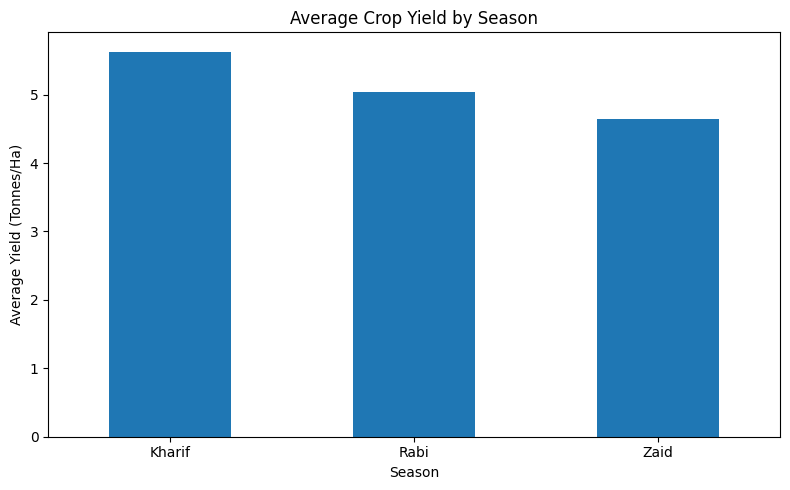

In [ ]:
import matplotlib.pyplot as plt

season_yield = data.groupby("Season")["Yield_Tonnes_Ha"].mean()

plt.figure(figsize=(8, 5))
season_yield.plot(kind="bar")

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Chart 2 — Average Profit by Season

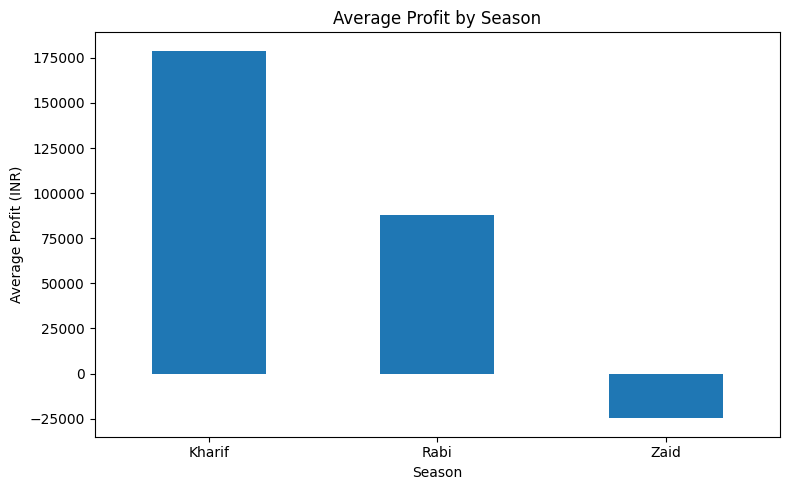

In [37]:
import matplotlib.pyplot as plt

season_profit = data.groupby("Season")["Profit_INR"].mean()

plt.figure(figsize=(8, 5))
season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Chart 3 — Average Yield by Crop

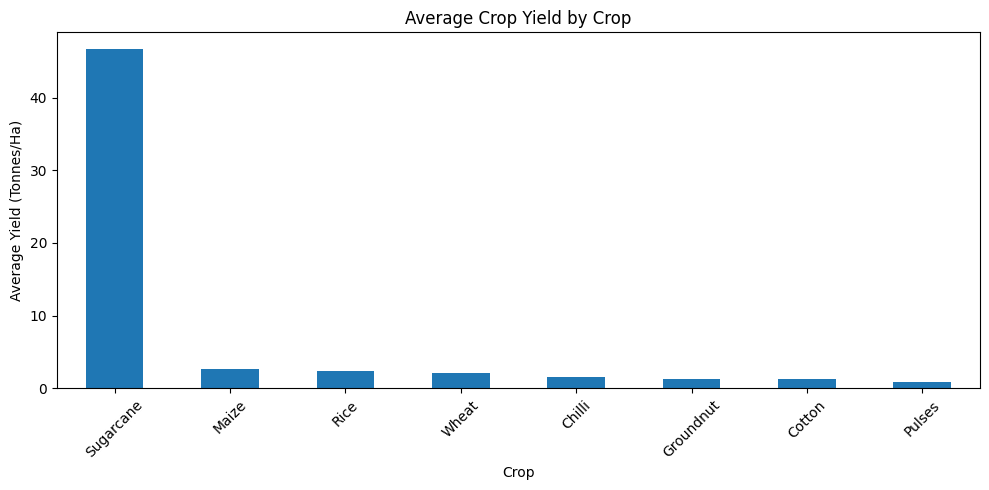

In [38]:
import matplotlib.pyplot as plt

crop_yield = data.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
crop_yield.plot(kind="bar")

plt.title("Average Crop Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Chart 4 — Average Profit by Crop

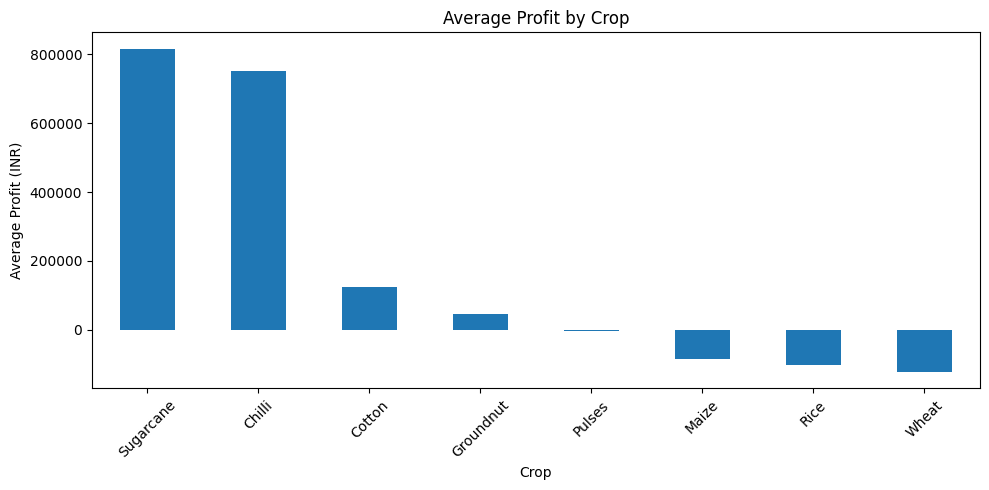

In [39]:
import matplotlib.pyplot as plt

crop_profit = data.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
crop_profit.plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Chart 5 — Average Yield by Irrigation Method

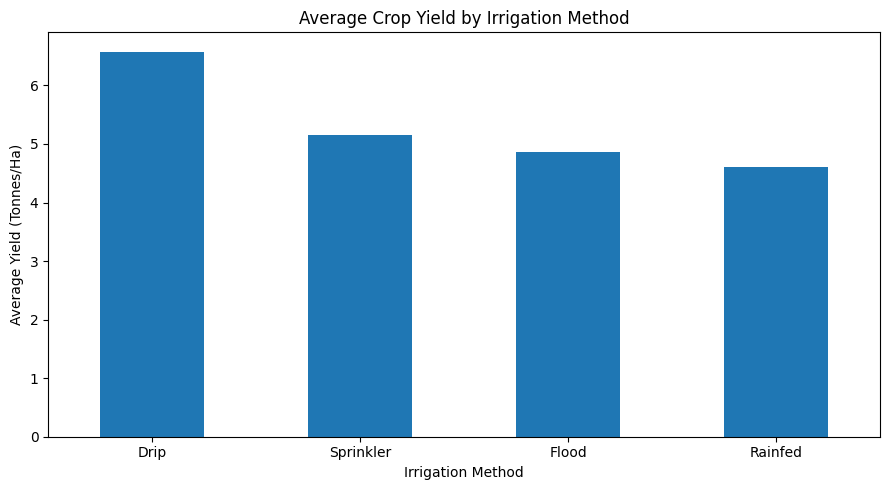

In [40]:
import matplotlib.pyplot as plt

irrigation_yield = data.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
irrigation_yield.plot(kind="bar")

plt.title("Average Crop Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Chart 6 — Average Revenue by Crop

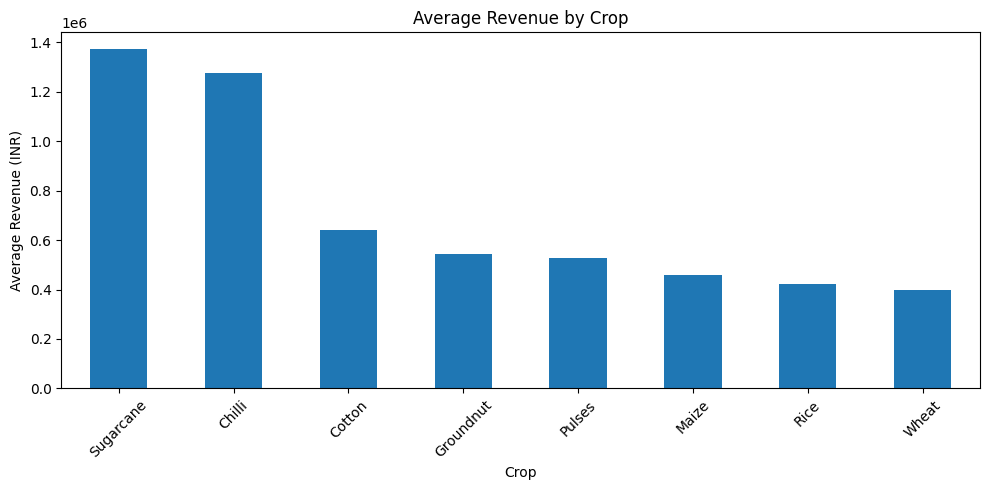

In [41]:
import matplotlib.pyplot as plt

crop_revenue = data.groupby("Crop")["Revenue_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
crop_revenue.plot(kind="bar")

plt.title("Average Revenue by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Chart 7 — Average Yield by State

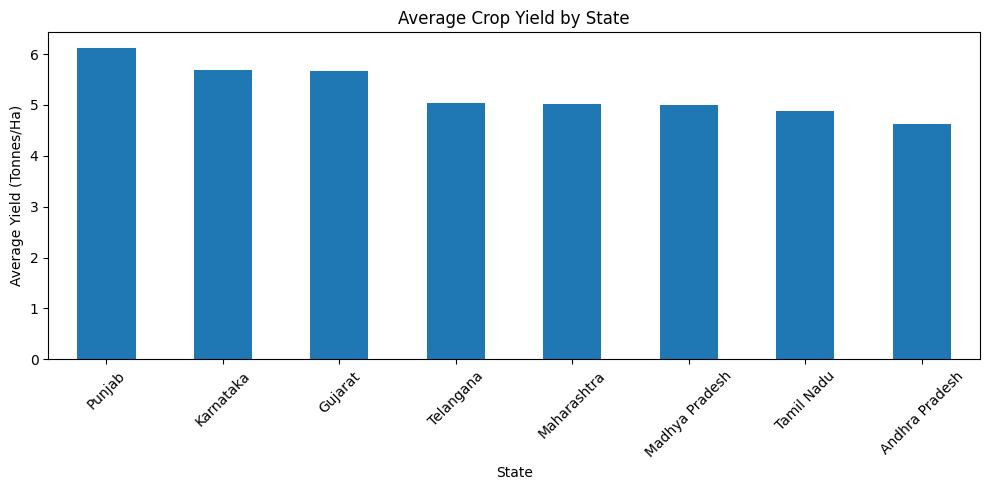

In [42]:
import matplotlib.pyplot as plt

state_yield = data.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
state_yield.plot(kind="bar")

plt.title("Average Crop Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Chart 8 — Average Disease/Pest Risk by Season

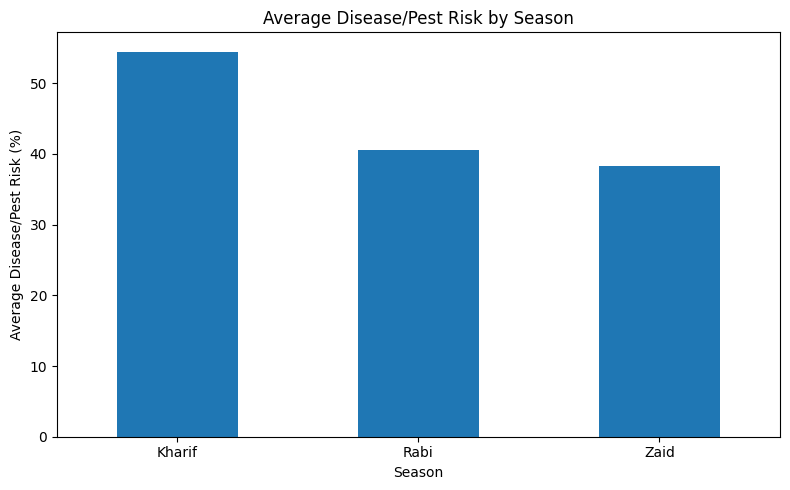

In [43]:
import matplotlib.pyplot as plt

season_risk = data.groupby("Season")["Disease_Pest_Risk_pct"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
season_risk.plot(kind="bar")

plt.title("Average Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Average Disease/Pest Risk (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Chart 9 — Rainfall vs Crop Yield

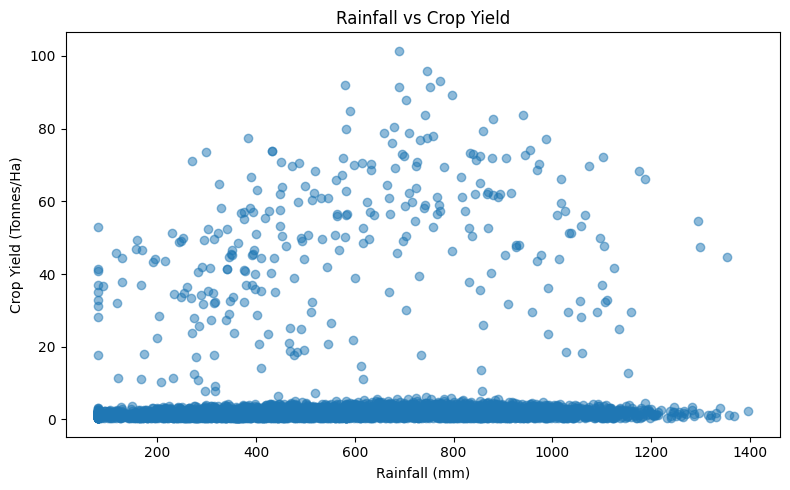

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(data["Rainfall_mm"], data["Yield_Tonnes_Ha"], alpha=0.5)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Crop Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

Chart 10 — Average Profit by Irrigation Method

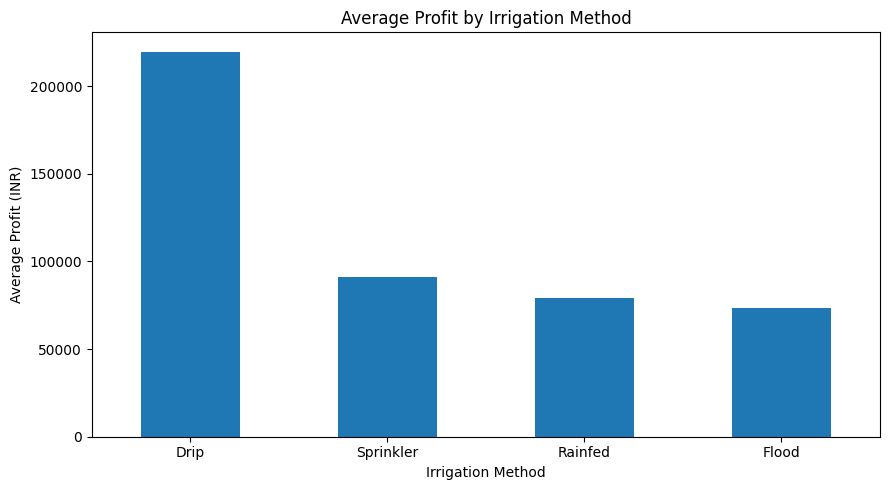

In [45]:
import matplotlib.pyplot as plt

irrigation_profit = data.groupby("Irrigation_Method")["Profit_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
irrigation_profit.plot(kind="bar")

plt.title("Average Profit by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()